# DATA MINING EN ECONOMIA Y FINANZAS. 2026
  Comisión jueves

# Tarea para el Hogar 02



Esta Tarea para el Hogar 02 llega a sus manos luego de la segunda clase.
<br> Se espera de usted que intente avanzar con los desafios propuestos y que los traiga terminados para la Clase 03, ya que se analizarán los resultados.

##  1. Ensembles de Modelos

Vea el siguiente video [BBC - The Code - The Wisdom of the Crowd](https://www.youtube.com/watch?v=iOucwX7Z1HU)    ( 5 min)


Lea los siguientes artículos


*   [The Wisdom of Crowds (Vox Populi) by Francis Galton](https://www.all-about-psychology.com/the-wisdom-of-crowds.html)  (10 min)
*   [A Gentle Introduction to Ensemble Learning](https://machinelearningmastery.com/what-is-ensemble-learning/)  (10 min)





---



##  2.  Zero2Hero   primera parte
Se han lanzado los primeros fascículos coleccionables llamados "from Zero to Hero" que muy detalladamente, paso a paso enseñan todo lo necesario de R para entender los scripts oficiales de la asignatura.
Están en el repositorio oficial de la asignatura, carpeta  **src/zero2hero**



---



## 3.  Grid Search

Busque en internet el preciso significado de los hiperparámetros de la librería **rpart**  que está implementando el algoritmo **CART**  Classification and Regression Trees  propuesto en el año 1984 por Leo Breiman:

*   cp
*   maxdepth
*   minsplit
*   minbucket

Entienda que valores podría tomar razonablemente cada hiperparámetro,  en particular profundice en el hiperparámetro  **cp**  y en la posibilidad de que tome valores negativos.  Es válido consultar a su amigo de *capacidades especiales*  Claude / ChatGPT


En las siguientes celdas encontrará un notebook incompleto, un esqueleto de código brindado a modo de facilitarle la tarea de codeo y permitir que su valiosa cognición se concentre en temas conceptuales de Ciencia de Datos.

Modifíquelo agregando loops para que recorra LOS 4 hiperparámetros de rpart  < cp, maxdepth, minsplit, minbucket >, y luego póngalo a correr. Recuerde cambiar por SU semilla
Tenga muy presente la granularidad que eligirá para cada hiperparámetro.

### Seteo del ambiente en Google Colab

Esta parte se debe correr con el runtime en Python3
<br>Ir al menu, Runtime -> Change Runtime Type -> Runtime type ->  **Python 3**

Conectar la virtual machine donde está corriendo Google Colab con el  Google Drive, para poder tener persistencia de archivos.

In [1]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')

Mounted at /content/.drive


los siguientes comandos estan en shell script de Linux

* Crear las carpetas en el Google Drive
* Bajar el competencia_01_crudo al Google Drive y tambien al disco local de la virtual machine que está corriendo Google Colab



In [2]:
%%shell

mkdir -p "/content/.drive/My Drive/dmeyf"
mkdir -p "/content/buckets"
ln -sfn "/content/.drive/My Drive/dmeyf" /content/buckets/b1


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets


# defino funcion descargar()
descargar() {
  carpeta_destino="/content/buckets/b1/datasets/"
  url_origen="https://storage.googleapis.com/open-courses/dmeyf2026-9c6f/"
  archivo="$1"

  if ! test -f "$carpeta_destino""$archivo"; then
    wget  "$url_origen""$archivo"  -O "$carpeta_destino""$archivo"
  fi

  if ! test -f  "/content/datasets/""$archivo"; then
    cp  "$carpeta_destino""$archivo"  "/content/datasets/""$archivo"
  fi;
}


# hago la descarga efectiva, llamando a descargar()
descargar  "competencia_01_crudo.csv"

## Generacion de la clase_ternaria

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

In [1]:
require( "data.table" )

# leo el dataset
dataset <- fread("/content/datasets/competencia_01_crudo.csv" )

# calculo el periodo0 consecutivo
dsimple <- dataset[, list(
    "pos" = .I,
    numero_de_cliente,
    periodo0 = as.integer(foto_mes/100)*12 +  foto_mes%%100 ) ]


# ordeno
setorder( dsimple, numero_de_cliente, periodo0 )

# calculo topes
periodo_ultimo <- dsimple[, max(periodo0) ]
periodo_anteultimo <- periodo_ultimo - 1


# calculo los leads de orden 1 y 2
dsimple[, c("periodo1", "periodo2") :=
    shift(periodo0, n=1:2, fill=NA, type="lead"),  numero_de_cliente ]

# assign most common class values = "CONTINUA"
dsimple[ periodo0 < periodo_anteultimo, clase_ternaria := "CONTINUA" ]

# calculo BAJA+1
dsimple[ periodo0 < periodo_ultimo &
    ( is.na(periodo1) | periodo0 + 1 < periodo1 ),
    clase_ternaria := "BAJA+1" ]

# calculo BAJA+2
dsimple[ periodo0 < periodo_anteultimo & (periodo0+1 == periodo1 )
    & ( is.na(periodo2) | periodo0 + 2 < periodo2 ),
    clase_ternaria := "BAJA+2" ]


# pego el resultado en el dataset original y grabo
setorder( dsimple, pos )
dataset[, clase_ternaria := dsimple$clase_ternaria ]

fwrite( dataset,
    file =  "/content/datasets/competencia_01.csv.gz",
    sep = ","
)

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%




In [2]:
setorder( dataset, foto_mes, clase_ternaria, numero_de_cliente)
dataset[, .N, list(foto_mes, clase_ternaria)]

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,CONTINUA,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,CONTINUA,161181
202105,BAJA+1,1143
202105,BAJA+2,870
202105,CONTINUA,161755


limpio el ambiente de R

In [3]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,740017,39.6,1473300,78.7,1473300,78.7
Vcells,1388298,10.6,170859661,1303.6,212615883,1622.2


In [4]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if (!require("primes")) install.packages("primes")
require("primes")

Loading required package: rpart

Loading required package: parallel

Loading required package: R.utils

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘R.utils’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully lo

Aqui debe poner SU semiila primigenia

In [5]:
PARAM <- list()
# reemplazar por su primer semilla
PARAM$semilla_primigenia <- 230047
PARAM$qsemillas <- 3

PARAM$training_pct <- 70L  # entre  1L y 99L

In [6]:
# particionar agrega una columna llamada fold a un dataset
#  que consiste en una particion estratificada segun agrupa
# particionar( data=dataset, division=c(70,30), agrupa=clase_ternaria, seed=semilla)
#   crea una particion 70, 30

particionar <- function(data, division, agrupa = "", campo = "fold", start = 1, seed = NA) {
  if (!is.na(seed)) set.seed(seed)

  bloque <- unlist(mapply(function(x, y) {
    rep(y, x)
  }, division, seq(from = start, length.out = length(division))))

  data[, (campo) := sample(rep(bloque, ceiling(.N / length(bloque))))[1:.N],
    by = agrupa
  ]
}


In [7]:
ArbolEstimarGanancia <- function(semilla, training_pct, param_basicos) {
  # particiono estratificadamente el dataset
  particionar(dataset,
    division = c(training_pct, 100L -training_pct),
    agrupa = "clase_ternaria",
    seed = semilla # aqui se usa SU semilla
  )

  # genero el modelo
  # predecir clase_ternaria a partir del resto
  modelo <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_basicos
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion <- predict(modelo, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad

  # prediccion es una matriz con TRES columnas,
  #  llamadas "BAJA+1", "BAJA+2"  y "CONTINUA"
  # cada columna es el vector de probabilidades


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test <- dataset[
    fold == 2,
    sum(ifelse(prediccion[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada <- ganancia_test / (( 100 - PARAM$training_pct ) / 100 )

  return(
    c( list("semilla" = semilla),
      param_basicos,
      list( "ganancia_test" = ganancia_test_normalizada )
     )
  )
}


In [8]:
ArbolesMontecarlo <- function(semillas, param_basicos) {

  # la funcion mcmapply  llama a la funcion ArbolEstimarGanancia
  #  tantas veces como valores tenga el vector  PARAM$semillas
  salida <- mcmapply(ArbolEstimarGanancia,
    semillas, # paso el vector de semillas
    MoreArgs = list(PARAM$training_pct, param_basicos), # aqui paso el segundo parametro
    SIMPLIFY = FALSE,
    mc.cores = detectCores()
  )

  return(salida)
}


In [78]:
# carpeta de trabajo
# por favor cambiar numero de experimento si se cambia el loop principal
setwd("/content/buckets/b1/exp")
experimento <- "HT2901"
dir.create(experimento, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

In [79]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz")

# trabajo solo con los datos de 202106, ultimo mes con clase_ternaria completa
# filtro datos
dataset <- dataset[foto_mes==202106]

invisible(gc(full=TRUE, verbose=FALSE)) # garbage collection

nrow(dataset)
dataset[, .N, clase_ternaria]

[1] 164114

clase_ternaria,N
<chr>,<int>
CONTINUA,162142
BAJA+2,1098
BAJA+1,874


In [80]:
# genero numeros primos
primos <- generate_primes(min = 100000, max = 1000000)
set.seed(PARAM$semilla_primigenia) # inicializo
# me quedo con PARAM$qsemillas   semillas
PARAM$semillas <- sample(primos, PARAM$qsemillas )


In [81]:
PARAM$semillas

[1] 389713 620377 736889

In [82]:
# genero la data.table donde van los resultados detallados del Grid Search
# un registro para cada combinacion de < semilla, parametros >

if(file.exists("gridsearch_detalle.txt")){
  tb_grid_search_detalle <- fread("gridsearch_detalle.txt")
}else{
  tb_grid_search_detalle <- data.table(
    semilla= integer(),
    cp= numeric(),
    maxdepth= integer(),
    minsplit= integer(),
    minbucket= integer(),
    ganancia_test= numeric()
  )
}

nrow( tb_grid_search_detalle )

[1] 0

Esta es la parte del código que usted debe expandir a TODOS los hiperparámetros de rpart,
<br>ya que actualmente apenas recorre  maxdepth y  minsplit  dejando fijos  cp=-0.5  y minbucket=5

In [14]:
# borramos tabla y memoria para cambiar la grilla y q no supongo q parte ya fué ejecutada
# tb_grid_search_detalle <- data.table()
# if (file.exists("gridsearch_detalle.txt")) file.remove("gridsearch_detalle.txt")

In [15]:

# itero por los loops anidados para cada hiperparametro
iter <- 0
depths <- c(3,4,5,6)
splits <- c(1750, 1500, 1250, 1000, 750)
cps = c(-2.5, -2, -1.5, -1, -0.5)
total_entrenamientos <- length(depths) *
                       length(splits) *
                       3 *                    # valores de minbucket
                       length(cps) *
                       PARAM$qsemillas

for (vmax_depth in depths) {
  cat("\n")
  cat( "****** VMAX ITERACION -> ",vmax_depth, " ******" )
  cat("\n")
  for (vmin_split in splits) {
      cat("\n")
      cat("VMIN ITERACION ", vmin_split, "\n")
      completados <- nrow(tb_grid_search_detalle)
      porcentaje <- 100 * completados / total_entrenamientos
      cat(sprintf(
        "Avance: %d de %d entrenamientos (%.1f%%)\n",
        completados,
        total_entrenamientos,
        porcentaje
      ))
    for (minbucket in round(c(vmin_split/2, vmin_split/3 ,vmin_split/4))) {
      for (cp in cps ) {
    # notar como se agrega
        iter <- iter + 1
        cat( iter, " " )
        # if (iter %% 50 == 0) cat("\n") # Agrega salto de línea cada 50
        flush.console()
        if( iter*PARAM$qsemillas < nrow(tb_grid_search_detalle)+1 ) next
        # vminsplit  minima cantidad de registros en un nodo para hacer el split
        param_basicos <- list(
          "cp"= cp, # complejidad minima
          "maxdepth"= vmax_depth, # profundidad máxima del arbol
          "minsplit"= vmin_split, # tamaño minimo de nodo para hacer split
          "minbucket"= minbucket # minima cantidad de registros en una hoja
        )

        # Un solo llamado, con la semilla 17
        ganancias <- ArbolesMontecarlo(PARAM$semillas, param_basicos)

        # agrego a la tabla
        tb_grid_search_detalle <- rbindlist(
          list( tb_grid_search_detalle,
                rbindlist(ganancias) )
        )

  }}}

  # grabo cada vez TODA la tabla en el loop mas externo
  fwrite( tb_grid_search_detalle,
          file= "gridsearch_detalle.txt",
          sep= "\t" )
}



****** VMAX ITERACION ->  3  ******

VMIN ITERACION  1750 
Avance: 675 de 900 entrenamientos (75.0%)
1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  
VMIN ITERACION  1500 
Avance: 675 de 900 entrenamientos (75.0%)
16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  
VMIN ITERACION  1250 
Avance: 675 de 900 entrenamientos (75.0%)
31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  
VMIN ITERACION  1000 
Avance: 675 de 900 entrenamientos (75.0%)
46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  
VMIN ITERACION  750 
Avance: 675 de 900 entrenamientos (75.0%)
61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  
****** VMAX ITERACION ->  4  ******

VMIN ITERACION  1750 
Avance: 675 de 900 entrenamientos (75.0%)
76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  
VMIN ITERACION  1500 
Avance: 675 de 900 entrenamientos (75.0%)
91  92  93  94  95  96  97  98  99  100  101  102  103  104  105  
VMIN ITERACION  1250 
Avance: 675 de 900 entrenamiento

In [16]:
fwrite( tb_grid_search_detalle,
   file= "gridsearch_detalle.txt",
   sep= "\t"
)

In [21]:
tb_grid_search_detalle <- fread("gridsearch_detalle.txt")

In [22]:
# cantidad de registros de la tabla
nrow(tb_grid_search_detalle)

[1] 900

In [23]:
# muestro la tabla
tb_grid_search_detalle

semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
<int>,<dbl>,<int>,<int>,<int>,<dbl>
389713,-2.5,3,1750,875,386925000
620377,-2.5,3,1750,875,393341667
736889,-2.5,3,1750,875,342191667
389713,-2.0,3,1750,875,386925000
620377,-2.0,3,1750,875,393341667
736889,-2.0,3,1750,875,342191667
389713,-1.5,3,1750,875,386925000
620377,-1.5,3,1750,875,393341667
736889,-1.5,3,1750,875,342191667


In [24]:
# genero y grabo el resumen
tb_grid_search <- tb_grid_search_detalle[,
  list( "ganancia_mean" = mean(ganancia_test),
    "qty" = .N ),
  list( cp, maxdepth, minsplit, minbucket )
]


In [25]:
# ordeno descendente por ganancia
setorder( tb_grid_search, -ganancia_mean )


In [65]:
# veo los 10 mejores hiperparámetros
tb_grid_search[1:10]

cp,maxdepth,minsplit,minbucket,ganancia_mean,qty,id
<dbl>,<int>,<int>,<int>,<dbl>,<int>,<int>
-2.5,6,1250,312,393494444,3,1
-2.0,6,1250,312,393494444,3,2
-1.5,6,1250,312,393494444,3,3
-1.0,6,1250,312,393494444,3,4
-0.5,6,1250,312,393494444,3,5
-2.5,6,1000,500,390988889,3,6
-2.0,6,1000,500,390988889,3,7
-1.5,6,1000,500,390988889,3,8
-1.0,6,1000,500,390988889,3,9


In [38]:
# genero un id a la tabla
tb_grid_search[, id := .I ]

fwrite( tb_grid_search,
  file= "gridsearch.txt",
  sep= "\t"
)


In [62]:
tb_grid_search[tb_grid_search$id %in% c(1,2,5,10,50,100),]

cp,maxdepth,minsplit,minbucket,ganancia_mean,qty,id
<dbl>,<int>,<int>,<int>,<dbl>,<int>,<int>
-2.5,6,1250,312,393494444,3,1
-2.0,6,1250,312,393494444,3,2
-0.5,6,1250,312,393494444,3,5
-0.5,6,1000,500,390988889,3,10
-0.5,6,1250,417,383563889,3,50
-0.5,5,750,375,378247222,3,100


In [71]:
# Cargar la librería necesaria
library(dplyr)

# 1. Crear el ranking con dense_rank() de mayor a menor
tabla_ranking <- tb_grid_search %>%
  mutate(posicion = dense_rank(desc(ganancia_mean)))

# 2. Filtrar para obtener los primeros 100 puestos del ranking
primeros_100 <- tabla_ranking %>%
  filter(posicion %in% c(1,2,5,10,50,100)) %>%
  arrange(posicion) # Ordenar visualmente del 1 al 100
primeros_100

cp,maxdepth,minsplit,minbucket,ganancia_mean,qty,id,posicion
<dbl>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>
-2.5,6,1250,312,393494444,3,1,1
-2.0,6,1250,312,393494444,3,2,1
-1.5,6,1250,312,393494444,3,3,1
-1.0,6,1250,312,393494444,3,4,1
-0.5,6,1250,312,393494444,3,5,1
-2.5,6,1000,500,390988889,3,6,2
-2.0,6,1000,500,390988889,3,7,2
-1.5,6,1000,500,390988889,3,8,2
-1.0,6,1000,500,390988889,3,9,2


In [77]:
# Agrupar por la columna 'posicion' y contar los registros
conteo_por_puesto <- tabla_ranking %>%
  group_by(posicion) %>%
  summarise(cantidad_registros = n(), .groups = "drop") %>%
  arrange(posicion) # Ordenar del puesto 1 en adelante
conteo_por_puesto

posicion,cantidad_registros
<int>,<int>
1,5
2,5
3,5
4,5
5,5
6,5
7,5
8,5
9,5


# 4.  Análisis de resultados de Grid Search

La salida de la corrida anterior queda en  exp/HT2900  que corresponde a su Google Drive
<br>HT significa Hyperparameter Tuning
<br>El Grid Search es un método de fuerza bruta de un altísimo costo computacional.
<br>Queremos ver si es posible crear un algoritmo de optimización de hiperparámetros que se ahorre recorrer ciertas porciones muy malas del espacio de búsqueda. Algo del estilo “cada vez que pruebo una combinación de hiperparámetros donde  cp > 1 , la ganancia es muy mala, con lo cual ni vale la pena perder el tiempo explorando en esa región”


<br>Levante el archivo de salida gridsearch.txt  a una planilla tipo Excel y analícelo detenidamente
<br>Ordene por ganancia_mean descendente, de la mejor a la peor
<br>En la Planilla Colaborativa, hoja "Grid Search"  cargue  la posición 1, 2, 5, 10, 50 y 100 de su salida
<br>
<br>El de mayor ganancia_mean  decimos que es el primero del ranking
En el channel  #J-Tarea Hogar 02 , topic Analisis Grid Search   intente contestar estas preguntas:

* ¿Qué combinaciones de hiperparámetros poseen una ganancia muy buena?
* ¿Hay algún hiperparámetro que para cierto valor siempre genera una ganancia muy mala, independientemente de lo que valgan los otros hiperparámetros?
* ¿Qué combinaciones de hiperparámetros es pésima y hubiera sido bueno ahorrarse esas corridas?

(tiempo estimado 30 minutos, dificultad media )


In [27]:
getwd()
list.files()
file.exists("gridsearch_detalle.txt")

[1] "/content/.drive/My Drive/dmeyf/exp/HT2900"

[1] "gridsearch_1sem.txt"         "gridsearch_detalle_1sem.txt"
[3] "gridsearch_detalle.txt"      "gridsearch.txt"

[1] TRUE

In [46]:
gridsearch <- read.delim(
  "gridsearch_detalle.txt",
  header = TRUE,
  sep = "\t"
)

head(gridsearch)
str(gridsearch)

,semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
,<int>,<dbl>,<int>,<int>,<int>,<dbl>
1,389713,-2.5,3,1750,875,386925000
2,620377,-2.5,3,1750,875,393341667
3,736889,-2.5,3,1750,875,342191667
4,389713,-2.0,3,1750,875,386925000
5,620377,-2.0,3,1750,875,393341667
6,736889,-2.0,3,1750,875,342191667


'data.frame':	900 obs. of  6 variables:
 $ semilla      : int  389713 620377 736889 389713 620377 736889 389713 620377 736889 389713 ...
 $ cp           : num  -2.5 -2.5 -2.5 -2 -2 -2 -1.5 -1.5 -1.5 -1 ...
 $ maxdepth     : int  3 3 3 3 3 3 3 3 3 3 ...
 $ minsplit     : int  1750 1750 1750 1750 1750 1750 1750 1750 1750 1750 ...
 $ minbucket    : int  875 875 875 875 875 875 875 875 875 875 ...
 $ ganancia_test: num  3.87e+08 3.93e+08 3.42e+08 3.87e+08 3.93e+08 ...


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



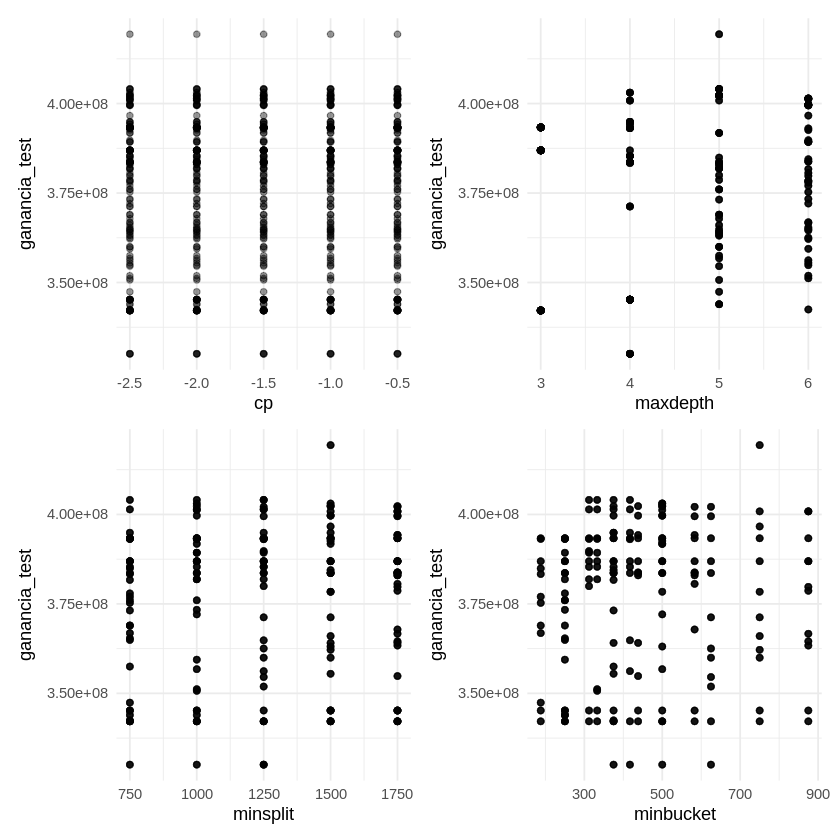

In [29]:
library(ggplot2)
install.packages("patchwork")
library(patchwork)

p_cp <- ggplot(gridsearch, aes(cp, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

p_depth <- ggplot(gridsearch, aes(maxdepth, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

p_split <- ggplot(gridsearch, aes(minsplit, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

p_bucket <- ggplot(gridsearch, aes(minbucket, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

(p_cp | p_depth) / (p_split | p_bucket)

In [34]:
sample <- gridsearch[gridsearch$maxdepth == 5 & gridsearch$ganancia_test > 0, ]
setorder(sample , -ganancia_test )
sample

,semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
,<int>,<dbl>,<int>,<int>,<int>,<dbl>
497,620377,-2.5,5,1500,750,419375000
500,620377,-2.0,5,1500,750,419375000
503,620377,-1.5,5,1500,750,419375000
506,620377,-1.0,5,1500,750,419375000
509,620377,-0.5,5,1500,750,419375000
557,620377,-2.5,5,1250,417,404066667
560,620377,-2.0,5,1250,417,404066667
563,620377,-1.5,5,1250,417,404066667
566,620377,-1.0,5,1250,417,404066667


In [58]:
# Reviso mejores resultados
# -2.5	6	1250	312	393494444	3	1
# -2.0	6	1250	312	393494444	3	2
# -1.5	6	1250	312	393494444	3	3
# -1.0	6	1250	312	393494444	3	4
# -0.5	6	1250	312	393494444	3	5
filtrado <- gridsearch[gridsearch$cp < -0.5 & gridsearch$maxdepth == 6 & gridsearch$minsplit == 1250  & gridsearch$minbucket == 312, ]

filtrado


,semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
,<int>,<dbl>,<int>,<int>,<int>,<dbl>
796,389713,-2.5,6,1250,312,389308333
797,620377,-2.5,6,1250,312,401408333
798,736889,-2.5,6,1250,312,389766667
799,389713,-2.0,6,1250,312,389308333
800,620377,-2.0,6,1250,312,401408333
801,736889,-2.0,6,1250,312,389766667
802,389713,-1.5,6,1250,312,389308333
803,620377,-1.5,6,1250,312,401408333
804,736889,-1.5,6,1250,312,389766667


In [35]:
# maximo con cp = 0
filtrado <- gridsearch[
  gridsearch$cp == 0 & gridsearch$ganancia_test > 0,
]
filtrado[which.max(filtrado$ganancia_test), ]

# maximo con cp >0
filtrado <- gridsearch[
  gridsearch$cp > 0 & gridsearch$ganancia_test > 0,
]
filtrado[which.max(filtrado$ganancia_test), ]

# maximo con cp <0
filtrado <- gridsearch[
  gridsearch$cp < 0 & gridsearch$ganancia_test > 0,
]
filtrado[which.max(filtrado$ganancia_test), ]

,semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
,<int>,<dbl>,<int>,<int>,<int>,<dbl>
804,389713,0,7,50,12,317258333


semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
<int>,<dbl>,<int>,<int>,<int>,<dbl>


,semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
,<int>,<dbl>,<int>,<int>,<int>,<dbl>
311,389713,-2,4,1500,500,403058333


# filrando alrededor de mi mejor modelo

In [39]:
filtrado <- gridsearch[
  gridsearch$cp <= -0.5 & gridsearch$minsplit >= 1000,
]



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



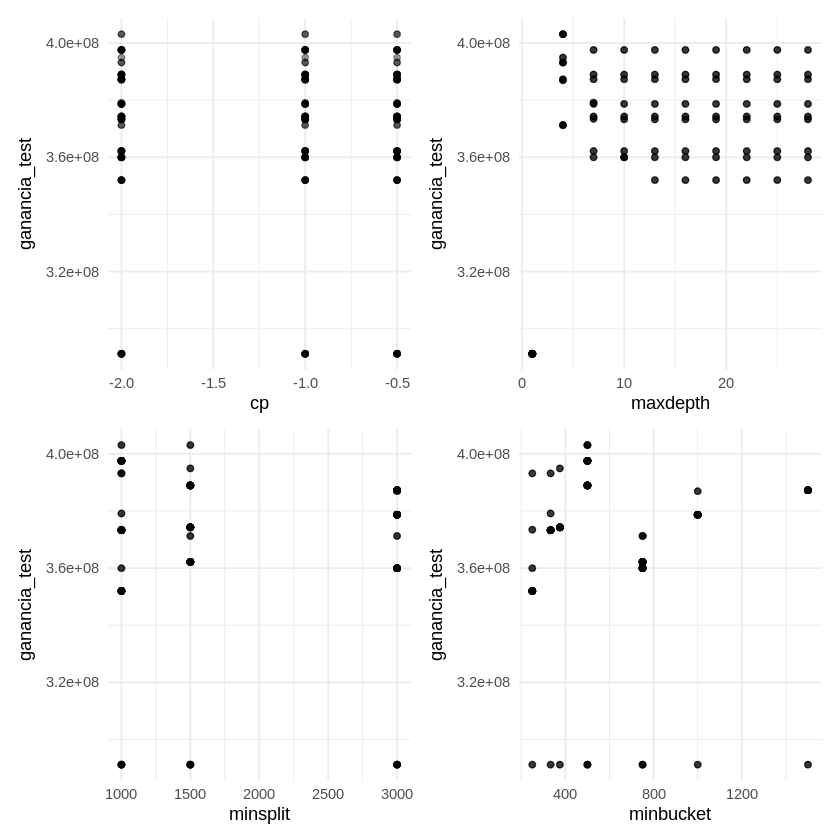

In [40]:
p_cp <- ggplot(filtrado, aes(cp, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

p_depth <- ggplot(filtrado, aes(maxdepth, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

p_split <- ggplot(filtrado, aes(minsplit, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

p_bucket <- ggplot(filtrado, aes(minbucket, ganancia_test)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

(p_cp | p_depth) / (p_split | p_bucket)